# 44-SMA Scanner — Top 500 Universe Scan

Runs the scanner (detection only — no P&L, no trades) across the full NSE
top-500 universe (`research_universe.example.json`). With 500 symbols x 2
directions, per-symbol charts aren't practical here — this notebook gives you
tables instead, and only charts the handful of symbols that are qualifying
**right now** (the "Live check" section) so you can still eyeball those.

For a deep-dive chart + manual arithmetic check on any specific symbol, use
`scanner_verification.ipynb` with that symbol in its `SYMBOLS` list.

Edit **Parameters**, then Run All.

In [1]:
from pathlib import Path
import sys

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'sma44_level1_intraday').exists():
            return p
    raise FileNotFoundError('Cannot find repo root')

REPO_ROOT = find_repo_root(Path.cwd())
for p in (REPO_ROOT, REPO_ROOT / 'src'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
REPO_ROOT

PosixPath('/home/rahul/trading2/trading_bot')

In [2]:
import dataclasses
import json
import time as _time
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sma44_level1_intraday.backtest.engine import ScannerBacktester
from sma44_level1_intraday.config.schema import StrategyConfig
from sma44_level1_intraday.pipeline import prepare_symbol_bars_for_scan
from sma44_level1_intraday.reporting import build_summary
from sma44_level1_intraday.resample import bars_lookback_start, is_daily_timeframe, is_weekly_timeframe
from sma44_level1_intraday.scanner import is_strong_directional_candle, scan_history, scan_symbol
from sma44_level1_intraday.setup_quality import enrich_touches_with_setup_quality
from sma44_level1_intraday.signals import (
    _TIMEFRAME_COLUMN_PREFIX, _daily_volume_reference, _higher_timeframe_trend_class_reference,
    _ma_alignment_reference, generate_scan_candidates, ma_alignment_letters, pending_setup_status,
)
from intraday_research.universe import load_universe

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.dpi'] = 100

## Parameters

In [3]:
# NIFTY Total Market (~750: largemidcap250 + smallcap250 + microcap250), built
# via scripts/build_nifty_universes.py from NSE's official index-membership CSVs —
# re-run that script to refresh after NSE's semi-annual reconstitution (Mar/Sep).
# For the COMPLETE NSE cash segment instead (~2,670 EQ-series symbols, incl. thin/
# illiquid names the curated lists screen out, built via
# scripts/build_full_cash_universe.py from FYERS' own symbol master):
#   UNIVERSE_FILE = REPO_ROOT / 'universe_full_cash_segment.json'          # everything, ETFs included
# Active default: same full cash segment, but with ETFs removed BEFORE fetch/scan
# even happens (hard check #5 -- no ETF ever gets cached, not just filtered out
# of candidates later; see universe_full_cash_segment_etf.json for the excluded list).
UNIVERSE_FILE = REPO_ROOT / 'universe_full_cash_segment_ex_etf.json'
# UNIVERSE_FILE = REPO_ROOT / 'universe_nifty_total_market750.json'
ASSET_TYPE = 'equity'
START_DATE = '2026-01-01'
END_DATE   = '2026-10-01'
TIMEFRAME  = '1W'

# F&O-eligible stocks (scripts/build_fno_universe.py, from NSE's own market-lot
# file) — SHORT candidates on a symbol NOT in this list are dropped in the
# BACKTEST section below (you generally can't short an Indian equity without an
# F&O market to borrow via). LONG is never affected. The scan/setup-quality
# sections above still show SHORT touches for every symbol regardless — that's
# detection/analysis, not a claim they're all tradeable.
FNO_UNIVERSE_FILE = REPO_ROOT / 'research_futures_universe.json'
# ETF membership within the cash-segment universe (see scripts/build_full_cash_universe.py) --
# only exists for the full-cash-segment universe; harmless (empty set) if unavailable/irrelevant.
ETF_UNIVERSE_FILE = REPO_ROOT / 'universe_full_cash_segment_etf.json'

# The scan itself always runs the FULL START_DATE..END_DATE window — shrinking
# START_DATE would starve the SMA/slope warmup AND make the scanner lose track
# of sequences that started earlier (see the notebook's own note above). If you
# only care about touches from some more recent date, filter the OUTPUT here
# instead: every summary/detail/setup-quality table below is restricted to
# touches on/after REPORT_FROM_DATE, but the underlying scan (and therefore
# touch_count/setup_quality, which both depend on full sequence history) is
# computed from the true START_DATE regardless. Set to None to see everything.
REPORT_FROM_DATE = '2026-01-01'

SCANNER_OVERRIDES = {
    # Which moving averages generate signals. Omit (default) = just the 44-SMA.
    # A list runs the same rules per MA; each signal MA is also confluence-checked
    # against every OTHER MA in the list (+ MA200_FILTER_OVERRIDES ma_length), and if
    # several MAs signal on one bar only the one FARTHEST from price is kept. An
    # earlier still-open signal on ANY MA blocks later signals on the same symbol.
    'signal_ma_lengths': [30, 44, 50, 200],
    # rule 3: touch-zone tolerance. Defaults to 'atr' (config-schema default,
    # timeframe-independent -- the same setting works on daily or 5-min bars
    # unchanged). 0.2x ATR is a rough cross-symbol estimate matched to the
    # 0.6% this was originally tuned against on DAILY bars (measured on
    # NSE:PRIVISCL-EQ/NSE:TATASTEEL-EQ) -- not itself independently
    # calibrated, so re-verify against real examples if results look off.
    # 'touch_tolerance_mode': 'atr',                # 'atr' (default) or 'percent'
    'touch_tolerance_atr_multiplier': 0.2,          # atr mode
    # 'touch_tolerance_pct': 0.6,                    # percent mode only -- the old daily-tuned value, for comparison/rollback
    # rule 5: no longer gates touch recognition at all -- it only classifies
    # each touch's trend_class ("A" cleanly rising / "B" flattish / "C"
    # falling), purely informational. ma_slope_lookback/min_ma_slope_pct set
    # the A-vs-not-A boundary (net slope over this many bars, individually
    # rising on every one of them for "A"; the mirrored negative threshold
    # for "C"; anything else is "B").
    # 'ma_slope_lookback': 5,
    # 'min_ma_slope_pct': 0.0,
    # rule 10: how far price must move away from the SMA before the NEXT
    # touch counts. Same atr/percent choice as touch_tolerance_mode above --
    # 'move_away_mode': 'atr',                      # 'atr' (default) or 'percent'
    'move_away_atr_multiplier': 0.6,                # atr mode -- rough cross-symbol estimate, see ScannerConfig docstring
    # 'move_away_pct': 2.0,                          # percent mode only -- the old daily-tuned value
    # 'minimum_touch_number': 2,
    'setup_expiry_bars': 1,   # rule 5: a triggered-nowhere setup is cancelled after this many bars
    # rule 6: a SUSTAINED close beyond the SMA resets the whole active sequence —
    # a brief 1-bar dip does not. Defaults (ATR-based, scales across timeframes):
    # 'sequence_reset_mode': 'atr',                # 'atr' or 'percent'
    # 'sequence_reset_atr_multiplier': 0.6,         # used if mode='atr'
    # 'sequence_reset_pct': 2.0,                    # used if mode='percent'
    # 'sequence_reset_consecutive_bars': 2,         # how many consecutive bars must clear the depth
}

# Trade-taking filter (see signals.py / scanner.is_strong_directional_candle):
# a touch still counts toward touch_count regardless of its candle's shape —
# this ONLY marks whether that specific touch's own candle is strong enough
# to actually trade (closes beyond its open AND within this fraction of its
# own high (long) / low (short) — filters a technically-green-but-weak candle
# like an inverted hammer).
MIN_CLOSE_POSITION = 0.6
# True (set here): a green candle is ALWAYS strong for a LONG touch,
# regardless of where it closed in its own range -- MIN_CLOSE_POSITION then
# only ever applies to the OPPOSITE-colour hammer-exception case below (a red
# candle on a LONG touch that's still a genuine bullish-hammer rejection).
# False restores the original rule: a same-colour candle ALSO needs its own
# close within MIN_CLOSE_POSITION of its extreme.
SKIP_CLOSE_POSITION_CHECK_FOR_SAME_COLOR = True

# Setup-quality checks (see setup_quality.py): also don't affect touch_count —
# they only label how GOOD an already-qualifying touch's pullback structure
# looks (swing length, pullback steepness, double bottom/top, resistance/
# support flip, range-bound detection), combined into one BEST/OK/BAD verdict.
SETUP_QUALITY_OVERRIDES = {
    # 'swing_best_min_bars': 4,
    # 'swing_best_max_bars': 6,
    # 'swing_short_max_bars': 3,
    # 'swing_bad_min_bars': 16,
    # double bottom/top and resistance/support-flip tolerances: same atr/
    # percent mode choice as touch_tolerance_mode above (see
    # SetupQualityConfig docstring) -- both now default to 'atr' (0.15x,
    # a rough cross-symbol estimate matched to the 0.5% daily-tuned value).
    # 'double_bottom_tolerance_mode': 'atr',           # 'atr' (default) or 'percent'
    # 'double_bottom_tolerance_atr_multiplier': 0.15,   # atr mode
    # 'double_bottom_tolerance_pct': 0.5,               # percent mode only -- the old daily-tuned value
    # 'resistance_flip_tolerance_mode': 'atr',
    # 'resistance_flip_tolerance_atr_multiplier': 0.15,
    # 'resistance_flip_tolerance_pct': 0.5,
    # 'resistance_flip_swing_lookback': 3,
    # 'resistance_flip_lookback_bars': 200,   # only pivots within this many bars of the touch count
    # 'resistance_flip_min_touches': 2,       # need at least this many confirmed pivots near the level
    # 'ongoing_range_width_mode': 'atr',   # 'atr' (default, travels across timeframes) or 'percent'
    # 'ongoing_range_max_width_pct': 5.0,             # only used if mode='percent'
    # 'ongoing_range_max_width_atr_multiplier': 1.8,  # only used if mode='atr'
    # 'ongoing_range_min_bars': 4,
    # 'close_range_lookback_bars': 10,
    # 'violent_pullback_max_decline_atr_multiplier': 1.0,  # gap+intrabar decline (x ATR) that forces setup_quality='BAD'
}

# Trade rules for the BACKTEST section at the end of this notebook (see
# signals.py / backtest/engine.py) — NOT used by the scan/setup-quality
# sections above, which only detect and label touches, never trades:
#   1. entry only once price breaks back past the touch candle's own high
#      (long) / low (short) — always on, not configurable here.
#      (entry buffer: fixed points, a flat % of close, or
#      atr_multiplier * ATR — same idea as the SL buffer below, see
#      entry_buffer_type in ENTRY_OVERRIDES).
#   2. the stop is the WIDEST (furthest from entry) of: the lowest low
#      (long) / highest high (short) across the touch candle and
#      stop_lookback_bars immediately before it, and the 44-SMA's own value
#      at the touch (the stop must never sit INSIDE the support line itself).
#      (SL buffer: fixed points, a flat % of close, or
#      atr_multiplier * ATR — a false-breakout margin that scales with
#      the stock's own recent volatility; see sl_buffer_type below).
#   3. one open position per symbol at a time — always on, not configurable
#      here (config.trade_limits.one_active_position_per_symbol).
#   4. if the stop level breaches before entry, the setup is invalidated
#      outright (not just left to expire) — always on.
#   5. a setup not triggered within setup_expiry_bars (see SCANNER_OVERRIDES
#      above) is cancelled.
#   6. target = entry +/- risk_reward * EITHER the signal candle's own
#      (high - low) ['signal_candle_range', default — independent of how
#      wide the stop above ends up being] OR (entry - stop) itself
#      ['dynamic_stop_multiple'] — see target_mode below.
#   7. a touch is rejected outright (never becomes a candidate at all) if a
#      200-SMA sits below the 44-SMA (long) / above it (short) AND within
#      ma200_nearby_tolerance_pct of the touch candle's own close — a real
#      200-SMA confluence sitting right on the setup, not just nearby.
ENTRY_OVERRIDES = {
    'entry_buffer_type': 'atr',   # rule 1 — 'points', 'pct', or 'atr'
    # 'entry_buffer_points': 0.0,
    # 'entry_buffer_pct': 0.0,
    'entry_buffer_atr_multiplier': 0.1,   # only used if entry_buffer_type='atr'
    'round_to_whole_number': True,   # round trigger to the nearest whole rupee if close (safe side only)
    'round_to_whole_number_tolerance_pct': 0.1,
}
STOP_LOSS_OVERRIDES = {
    'stop_lookback_bars': 3,   # rule 2
    'sl_buffer_type': 'atr',   # rule 2a — 'points', 'pct', or 'atr'
    # 'sl_buffer_points': 0.0,
    # 'sl_buffer_pct': 0.0,
    'sl_buffer_atr_multiplier': 0.1,   # only used if sl_buffer_type='atr'
}
TARGET_OVERRIDES = {
    'risk_reward': 2.0,                        # rule 6
    'target_mode': 'signal_candle_range',       # rule 6 — or 'dynamic_stop_multiple'
}
# How an OPEN position exits (see backtest/engine.py's own _resolve_exit /
# ExecutionConfig) -- a separate concern from TARGET_OVERRIDES above, which
# only sets the FIXED target price a new candidate is born with. The switch
# below decides whether a trade actually uses that fixed target or instead
# trails.
#   'fixed'          -- initial stop + the fixed risk_reward target above (default,
#                        what every backtest run so far has used).
#   'atr_chandelier' -- an ATR-based trailing stop that only starts trailing once
#                        price has moved trail_after_R in your favour (until then
#                        the ORIGINAL signal stop still protects a losing trade
#                        unchanged); the fixed target is ignored once trailing is
#                        live -- see ExecutionConfig's own docstring for the full
#                        mechanics (never repaints, only ever ratchets favourably).
#   'candle_trail'   -- simpler: trails to the previous completed candle's own
#                        extreme, one bar delayed. Also ignores the fixed target.
# Leave at 'fixed' unless you deliberately want to compare against a trailing
# exit -- switching this changes exit_reason values in the trade journal too
# (e.g. "trail_stop" / a chandelier-specific reason instead of "sl"/"target").
EXECUTION_OVERRIDES = {
    'exit_mode': 'atr_chandelier',   # 'fixed' (default) | 'atr_chandelier' | 'candle_trail'
    # -- atr_chandelier-only knobs below; irrelevant while exit_mode='fixed' --
    'atr_length': 14,
    'atr_multiplier': 2,            # chandelier width, in ATRs, from the run-up extreme
    # 'swing_lookback': 5,              # confirmed swing pivot = extreme vs N bars each side
    # 'use_structure_filter': True,     # also pull the stop to the last confirmed swing
    # 'trail_after_R': 1.0,             # arm trailing only once price reaches this many R
    'exit_on_close': False,            # True: exit only on a CLOSE beyond the stop; False: any intrabar touch
    # 'use_breakeven_after_activation': True,   # on arming, pull the stop to at least breakeven
}
MA200_FILTER_OVERRIDES = {
    'ma_length': 200,               # rule 7 — also how far FETCH_START_DATE below gets padded back
    # 'nearby_tolerance_mode': 'atr',  # 'atr' (default) or 'percent' -- see Ma200FilterConfig docstring
    'nearby_tolerance_atr_multiplier': 1.5,  # rule 7, atr mode -- rough cross-symbol estimate matched to the old 5.0% daily-tuned value
    # 'nearby_tolerance_pct': 5.0,    # percent mode only -- the old daily-tuned value
    # 0 (default) = off. > 0: a nearby reference MA that would reject the touch is WAIVED when it
    # sits within this many ATR of the signal MA itself (MAs practically merged into one band).
    # The candidate/trade/live tables then show confluence_gap_skipped / _ma / _atr.
    'merged_ma_gap_atr_multiplier': 0.3,
}
# Hard checks (see TradeFilterConfig) -- each independently drops a touch from
# ever becoming a trade candidate, same "trade-taking filter" category as
# MA200_FILTER_OVERRIDES above (touch_count/sequence is never affected):
#   1. no "B"-class (flattish-MA) trades at all.
#   2. "C"-class (MA against the trade) trades still need a slope no worse
#      than -1.5% (direction-adjusted -- see TradeFilterConfig docstring).
#   3. today's volume must be >= 100,000 shares.
#   4. the computed entry (trigger_price) must be >= Rs 15.
# (ETFs -- hard check #5 -- are handled separately, at the UNIVERSE_FILE level
# above: universe_full_cash_segment_ex_etf.json excludes them before fetch/scan
# even happens, so there's nothing to filter here.)
TRADE_FILTER_OVERRIDES = {
    'exclude_trend_class_b': True,
    'min_trend_class_c_slope_pct': -1.5,
    'min_daily_volume': 10_000.0,
    'min_entry_price': 15.0,
}

# Position sizing for the BACKTEST section (see risk.py / backtest/engine.py's
# _compute_qty) -- purely how many shares/lots each trade uses; does not
# affect touch detection, setup quality, or trigger/stop/target levels.
# 'fixed_qty' (default): every trade uses the same RISK_OVERRIDES['fixed_qty'] units.
# 'risk_per_trade': qty = risk_amount / abs(trigger_price - stop_loss), where
#   risk_amount is risk_per_trade_amount if set, else current_equity *
#   risk_per_trade_pct/100 -- "risk a fixed amount (or %) of capital on every
#   trade, sized wider or narrower purely by how far the stop sits from entry".
# 'capital_based': qty = capital_amount / trigger_price (capital_amount = the
#   fixed amount if set, else a % of current equity) -- deploys roughly the same
#   RUPEE EXPOSURE on every trade regardless of its stop distance.
RISK_OVERRIDES = {
    'initial_capital': 2_500_000,
    'position_sizing_mode': 'capital_based',   # 'fixed_qty', 'risk_per_trade', or 'capital_based'
    # 'risk_per_trade_amount': 25_000,   # fixed ₹ risk per trade -- overrides risk_per_trade_pct when set
    'risk_per_trade_pct': 0.25,          # risk 0.25% of current equity per trade -- overrides via risk_per_trade_amount if you'd rather use a flat rupee figure
    'capital_per_trade_amount': 200_000,
    # 'capital_per_trade_pct': 10.0,
    'max_daily_loss_pct': 100.0,
}

SKIP_ON_LOAD_ERROR = True   # don't let one bad/delisted symbol kill the whole run
EXPORT_CSV = REPO_ROOT / 'artifacts' / 'scanner_universe_scan.csv'
TRADE_JOURNAL_CSV = REPO_ROOT / 'artifacts' / 'scanner_universe_backtest_trades.csv'

# The 200-SMA (rule 7) needs ma_length bars of history BEFORE it can say
# anything — if START_DATE is recent, fetching only from START_DATE onward
# would leave the 200-SMA (and the rule 7 filter it drives) silently
# inactive for the whole opening ma_length-bar stretch. Pad the actual FETCH
# back accordingly; START_DATE itself stays what you set — everything below
# still scans/backtests through to END_DATE, REPORT_FROM_DATE still trims
# the output tables exactly as before.
FETCH_START_DATE = bars_lookback_start(
    date.fromisoformat(START_DATE), TIMEFRAME, MA200_FILTER_OVERRIDES['ma_length'],
).isoformat() if (is_daily_timeframe(TIMEFRAME) or is_weekly_timeframe(TIMEFRAME)) else START_DATE

## Auto top-up fetch (daily/weekly only)

Before scanning, batch-fetch any days missing since the last run for the
**whole universe in one pass** — this hits the exact same on-disk cache
(`data/fyers_daily/`) the scan loop below reads from, so if you already ran
this today, it costs almost nothing (a local coverage check per symbol, no
network call). Skipping this step doesn't break anything — `prepare_symbol_bars_for_scan`
below would still fetch whatever's missing — but it would do it **live, one
symbol at a time**, inside the scan loop. With ~2,668 symbols and FYERS'
per-account rate limit, that turns a few-seconds top-up into HOURS (this is
exactly what made earlier runs slow). Batching it here first avoids that.

In [4]:
FYERS_USER_KEY = 'user1'   # which fyers_auth.json account to fetch with

if is_daily_timeframe(TIMEFRAME) or is_weekly_timeframe(TIMEFRAME):
    import subprocess
    t0 = _time.time()
    proc = subprocess.Popen(
        [sys.executable, str(REPO_ROOT / 'scripts' / 'fetch_fyers_universe_data.py'),
         '--auth-file', 'fyers_auth.json', '--user-key', FYERS_USER_KEY,
         '--universe-file', str(UNIVERSE_FILE),
         '--start', FETCH_START_DATE, '--end', END_DATE,
         '--output-dir', 'data/fyers_daily', '--format', 'parquet',
         '--resolution', 'D', '--chunk-days', '365', '--skip-invalid-symbols'],
        cwd=REPO_ROOT, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1,
    )
    # Stream instead of capture_output=True -- capturing silently until the
    # whole subprocess exits means a NORMAL, fast run (usually well under a
    # minute when the cache is warm) shows zero output the entire time and
    # looks indistinguishable from a genuine hang. Printing periodically
    # here proves it's alive and shows real progress either way.
    n_lines = 0
    for line in proc.stdout:
        n_lines += 1
        if n_lines % 200 == 0 or 'RATE_LIMIT' in line or 'rror' in line:
            print(f'[{_time.time()-t0:.0f}s, line {n_lines}] {line.rstrip()}')
    proc.wait()
    elapsed = _time.time() - t0
    print(f'top-up fetch finished in {elapsed:.0f}s (exit code {proc.returncode}, {n_lines} lines total)')
    if proc.returncode != 0:
        raise RuntimeError('top-up fetch failed (exit code %d) -- see output above' % proc.returncode)

    # The fetch script ALSO writes a throwaway per-run snapshot file per
    # symbol (NSE_X_EQ_<FETCH_START_DATE>_<END_DATE>.parquet) alongside the
    # real gap-aware master cache (NSE_X_EQ.parquet + .meta.json) -- since
    # FETCH_START_DATE/END_DATE shift run to run, every distinct pair leaves
    # a new set of ~2668 files behind if not cleaned up. Only the master
    # cache is ever read by anything downstream.
    snapshot_glob = f'data/fyers_daily/*_{FETCH_START_DATE}_{END_DATE}.parquet'
    removed = 0
    for f in (REPO_ROOT / 'data' / 'fyers_daily').glob(f'*_{FETCH_START_DATE}_{END_DATE}.parquet'):
        f.unlink()
        removed += 1
    print(f'cleaned up {removed} throwaway snapshot files ({snapshot_glob})')
else:
    print('intraday timeframe -- skipping the daily top-up fetch (1-minute data has its own on-demand cache).')

[13s, line 1] 2026-10-02 12:52:33 | WARNING | fyers | Retryable error (BrokerError). attempt=1 sleep=0.57s
[14s, line 2] 2026-10-02 12:52:34 | WARNING | fyers | Retryable error (BrokerError). attempt=2 sleep=1.23s
[15s, line 3] 2026-10-02 12:52:35 | WARNING | fyers | Retryable error (BrokerError). attempt=3 sleep=1.99s
[17s, line 4] 2026-10-02 12:52:38 | WARNING | fyers | Retryable error (BrokerError). attempt=4 sleep=5.98s
[108s, line 80] NSE:ADROITINFO-EQ: skipped invalid symbol (NSE:ADROITINFO-EQ is on record as an invalid/delisted Fyers symbol (marked 2026-10-01: Failed after 4 retries. last_error=BrokerError("History error: {'code': -300, 'message': 'Invalid symbol provided', 's': 'error'}")) — skipping without a network call. Delete its entry in /home/rahul/trading2/trading_bot/data/fyers_invalid_symbols.json to force a re-check.)
[108s, line 133] NSE:ALKALI-EQ: skipped invalid symbol (NSE:ALKALI-EQ is on record as an invalid/delisted Fyers symbol (marked 2026-09-25: Failed after

[450s, line 1834] NSE:MILKYMIST-EQ: skipped invalid symbol (NSE:MILKYMIST-EQ is on record as an invalid/delisted Fyers symbol (marked 2026-09-25: Failed after 4 retries. last_error=BrokerError("History error: {'code': -300, 'message': 'Invalid symbol provided', 's': 'error'}")) — skipping without a network call. Delete its entry in /home/rahul/trading2/trading_bot/data/fyers_invalid_symbols.json to force a re-check.)
[450s, line 1869] NSE:MONEYBOXX-EQ: skipped invalid symbol (NSE:MONEYBOXX-EQ is on record as an invalid/delisted Fyers symbol (marked 2026-10-02: Failed after 4 retries. last_error=BrokerError("History error: {'code': -300, 'message': 'Invalid symbol provided', 's': 'error'}")) — skipping without a network call. Delete its entry in /home/rahul/trading2/trading_bot/data/fyers_invalid_symbols.json to force a re-check.)
[463s, line 2000] NSE:NPST-EQ: 2022-04-07 -> 2022-04-17 looked incomplete (0/7 expected trading days) — recording only what was actually received; the rest wi

top-up fetch finished in 855s (exit code 0, 5852 lines total)
cleaned up 2294 throwaway snapshot files (data/fyers_daily/*_2022-02-03_2026-10-01.parquet)


## Load + scan every symbol in the universe

For TIMEFRAME "1D"/"1W" this never loads 1-minute data at all — it goes
straight to Fyers' NATIVE daily candles (the exchange-official close,
matching your broker) via `prepare_symbol_bars_for_scan`, keyed off
**FETCH_START_DATE**/END_DATE (not the bare START_DATE you set — see
Parameters: FETCH_START_DATE is START_DATE auto-padded back by the 200-SMA's
own warmup, so rule 7's filter is already valid right from START_DATE, not
just 200 bars after it). Skipping the 1-minute load is most of the speedup on
a "we already have the data" re-run: it was previously loaded on every
symbol, every run, purely to read off two dates we already know as plain
strings. For intraday timeframes it still loads and resamples 1-minute data,
same as before.

Symbols Fyers has confirmed are invalid/delisted are recorded the first time
(`data/fyers_invalid_symbols.json`) and skipped with zero network calls on
every later run — delete a symbol's entry there (or the whole file) to force
a re-check. Everything else missing from the local cache is reported and
skipped rather than triggering a live fetch here — run the universe fetch
script first if you see a lot of those instead.

In [5]:
config = StrategyConfig.from_dict({
    'timeframes': {'timeframe': TIMEFRAME},
    'scanner': SCANNER_OVERRIDES,
    'setup_quality': SETUP_QUALITY_OVERRIDES,
    # Wired into config (not just used as a bare local below) so the BACKTEST
    # section's generate_scan_candidates() applies the identical candle-strength
    # filter as the is_strong_candle column above — same MIN_CLOSE_POSITION either way.
    'signal_candle': {
        'min_close_position': MIN_CLOSE_POSITION,
        'skip_close_position_check_for_same_color_candle': SKIP_CLOSE_POSITION_CHECK_FOR_SAME_COLOR,
    },
    'ma200_filter': MA200_FILTER_OVERRIDES,
    'trade_filters': TRADE_FILTER_OVERRIDES,
    'entry': ENTRY_OVERRIDES,
    'stop_loss': STOP_LOSS_OVERRIDES,
    'target': TARGET_OVERRIDES,
    'execution': EXECUTION_OVERRIDES,
    'risk': RISK_OVERRIDES,
    # A daily/weekly bar is timestamped once for the whole session (e.g.
    # 05:30 IST, before market_start_time) — the engine's intraday
    # no_new_entry_after/force_exit_time gates would otherwise silently
    # reject every candidate before it's even added to the pending queue
    # (0 trades, 0 rejections logged — nothing to point at). continuous_session
    # turns those intraday-only gates off; only relevant for the BACKTEST
    # section below, the scan/setup-quality sections above never use them.
    'market': {'continuous_session': is_daily_timeframe(TIMEFRAME) or is_weekly_timeframe(TIMEFRAME)},
})

universe = load_universe(UNIVERSE_FILE)
print(f'universe: {universe.name}  ({len(universe.symbols)} symbols)')

# research_futures_universe.json's 'symbols' are objects (underlying/lot_size/...),
# not the flat string list load_universe() expects — read it directly instead.
fno_symbols = {s['symbol'] for s in json.loads(FNO_UNIVERSE_FILE.read_text())['symbols']}
print(f'F&O-eligible: {len(fno_symbols)} symbols (SHORT candidates outside this set are dropped in the backtest)')

# ETFs mixed into the cash-segment universe (built via scripts/build_full_cash_universe.py
# from FYERS' own symbol master's instrument-type code) — flagged, not excluded, since an
# ETF touch can still be a legitimate setup, just a different risk profile than a single stock.
etf_symbols = set(load_universe(ETF_UNIVERSE_FILE).symbols) if ETF_UNIVERSE_FILE.exists() else set()
print(f'ETFs in universe: {len(etf_symbols)} symbols (flagged via is_etf below, not excluded)')

market_bars = {}       # symbol -> bars (kept small: one row per TIMEFRAME bar)
all_events = []
skipped = []
t0 = _time.time()

for n, sym in enumerate(universe.symbols, 1):
    try:
        bars = prepare_symbol_bars_for_scan(sym, FETCH_START_DATE, END_DATE, config,
                                            asset_type=ASSET_TYPE, repo_root=REPO_ROOT, verbose=False)
    except Exception as e:
        skipped.append((sym, f'load error: {str(e)[:80]}'))
        if not SKIP_ON_LOAD_ERROR:
            raise
        continue
    if bars.empty:
        skipped.append((sym, 'no cached data'))
        continue
    symbol_key = bars['symbol'].iloc[0]
    market_bars[symbol_key] = bars
    for ma_n in config.scanner.ma_lengths():
        scanner_cfg = dataclasses.replace(config.scanner, sma_length=ma_n)
        events = scan_history(bars, scanner_cfg, symbol=symbol_key, timeframe=TIMEFRAME)
        if not events.empty:
            # Trade-taking filter, computed per touch but NOT fed back into
            # touch_count/qualification — a weak-candle touch still shows up here
            # with its real touch_count, just flagged as not tradeable.
            events = events.copy()
            events['ma_length'] = ma_n
            # A = all signal MAs agree with the trade (rising for LONG / falling for
            # SHORT), B = one doesn't, C = two, ... (see signals.ma_alignment_letters)
            events = events.merge(_ma_alignment_reference(bars, config.scanner), on='timestamp', how='left')
            events['ma_alignment'] = ma_alignment_letters(
                events['direction'], events['_ma_rising'].fillna(0), events['_ma_falling'].fillna(0),
                events['_ma_total'].fillna(len(config.scanner.ma_lengths())))
            events = events.drop(columns=['_ma_rising', '_ma_falling', '_ma_total'])
            events['is_strong_candle'] = events.apply(
                lambda r: is_strong_directional_candle(
                    r['direction'], r['open'], r['high'], r['low'], r['close'], MIN_CLOSE_POSITION,
                    config.signal_candle.allow_hammer_exception,
                    config.signal_candle.hammer_max_opposite_wick_ratio,
                    config.signal_candle.hammer_max_body_ratio,
                    config.signal_candle.skip_close_position_check_for_same_color_candle,
                ),
                axis=1,
            )
            # Setup-quality labels (see setup_quality.py) — also computed per touch,
            # also NOT fed back into touch_count/qualification.
            events = enrich_touches_with_setup_quality(bars, events, scanner_cfg, config.setup_quality)
            # Daily volume — ALWAYS the full calendar day's volume regardless of
            # TIMEFRAME (see signals._daily_volume_reference's own docstring: for
            # an intraday timeframe this sums same-day bars back together, not
            # just that one bar's own slice). Symbol-level, so is_etf is the same
            # for every row of a given symbol.
            vol_ref = _daily_volume_reference(bars)
            events = events.merge(vol_ref, on='timestamp', how='left').rename(columns={'_daily_volume': 'daily_volume'})
            events['is_etf'] = symbol_key in etf_symbols
            # Higher-timeframe trend_class context (see signals.higher_timeframes) --
            # e.g. for a daily scan, also shows what the 44-SMA is doing on the
            # weekly/monthly timeframe, using the LAST FULLY COMPLETED period as of
            # each touch (no lookahead). Purely informational, like trend_class
            # itself -- never affects touch_count/qualification.
            htf_ref = _higher_timeframe_trend_class_reference(
                bars, TIMEFRAME, config.market,
                scanner_cfg.sma_length, scanner_cfg.ma_slope_lookback, scanner_cfg.min_ma_slope_pct,
            )
            events = events.merge(htf_ref, on='timestamp', how='left')
            is_long_evt = (events['direction'] == 'LONG').to_numpy()
            for prefix in _TIMEFRAME_COLUMN_PREFIX.values():
                long_col, short_col = f'_{prefix}_class_long', f'_{prefix}_class_short'
                if long_col in events.columns:
                    events[f'{prefix}_trend_class'] = np.where(is_long_evt, events[long_col], events[short_col])
                    events = events.drop(columns=[long_col, short_col])
                else:
                    events[f'{prefix}_trend_class'] = None
            all_events.append(events)

    if n % 50 == 0:
        print(f'  ... {n}/{len(universe.symbols)} symbols scanned ({_time.time()-t0:.0f}s elapsed)')

events_df = pd.concat(all_events, ignore_index=True) if all_events else pd.DataFrame()
print(f"\nScanned {len(market_bars)} symbols ({len(skipped)} skipped) in {_time.time()-t0:.0f}s")
print(f'Total qualifying touch events: {len(events_df)}')
if skipped:
    print(f'\nFirst 10 skipped: {skipped[:10]}')

universe: nse_full_cash_segment_ex_etf  (2319 symbols)
F&O-eligible: 210 symbols (SHORT candidates outside this set are dropped in the backtest)
ETFs in universe: 351 symbols (flagged via is_etf below, not excluded)
  Fyers NSE:AAATECH-EQ: 2022-02-03 → 2022-11-27 looked incomplete (0/212 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:ABCOTS-EQ: 2023-05-12 → 2023-05-17 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:ABCOTS-EQ: 2023-05-25 → 2023-05-31 looked incomplete (0/5 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:ABCOTS-EQ: 2023-06-02 → 2023-06-11 looked incomplete (0/6 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:ABCOTS-EQ: 2023-06-17 → 2023-06-21 looked incomplete (0/3 expected tr

  Fyers NSE:BCG-EQ: 2024-09-10 → 2024-09-15 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:BCG-EQ: 2024-09-17 → 2024-09-22 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:BCG-EQ: 2024-09-24 → 2024-09-29 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:BCG-EQ: 2024-10-01 → 2024-10-06 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:BCG-EQ: 2024-10-08 → 2024-10-13 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:BCG-EQ: 2024-10-15 → 2024-10-20 looked incomplete (0/4 expected trading days) — recording only what was actually received; the r

  Fyers NSE:BLUECOAST-EQ: 2024-02-20 → 2024-03-31 looked incomplete (0/29 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:BLUECOAST-EQ: 2024-04-02 → 2024-06-30 looked incomplete (0/64 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:BLUECOAST-EQ: 2024-07-02 → 2024-07-14 looked incomplete (0/9 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:BLUECOAST-EQ: 2024-07-16 → 2024-08-04 looked incomplete (0/14 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:BLUECOAST-EQ: 2024-08-06 → 2024-08-18 looked incomplete (0/9 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:BLUECOAST-EQ: 2024-08-20 → 2024-08-25 looked incomplete (0/4 expected trading days) — recording

  Fyers NSE:BOHRAIND-EQ: 2025-02-25 → 2025-03-02 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  ... 350/2319 symbols scanned (137s elapsed)
  Fyers NSE:BTML-EQ: 2022-02-03 → 2023-01-01 looked incomplete (0/237 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:BTML-EQ: 2023-01-06 → 2023-02-14 looked incomplete (0/28 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  ... 400/2319 symbols scanned (153s elapsed)
  Fyers NSE:COFFEEDAY-EQ: 2024-11-05 → 2024-11-10 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:COFFEEDAY-EQ: 2024-11-12 → 2024-11-17 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:COFFEEDAY-EQ: 

  Fyers NSE:DRCSYSTEMS-EQ: 2022-03-15 → 2022-03-20 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:DRCSYSTEMS-EQ: 2022-03-22 → 2022-03-27 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:DRCSYSTEMS-EQ: 2022-03-29 → 2022-04-03 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:DRCSYSTEMS-EQ: 2022-04-05 → 2022-04-10 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:DRCSYSTEMS-EQ: 2022-04-26 → 2022-05-01 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:DRCSYSTEMS-EQ: 2022-05-03 → 2022-05-22 looked incomplete (0/14 expected trading days) — recor

...

  Fyers NSE:UEL-EQ: 2025-01-21 → 2025-01-26 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:UEL-EQ: 2025-01-28 → 2025-01-31 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:UEL-EQ: 2025-02-12 → 2025-02-16 looked incomplete (0/3 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:UEL-EQ: 2025-02-18 → 2025-02-23 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:UEL-EQ: 2025-02-25 → 2025-03-02 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:UEL-EQ: 2025-03-04 → 2025-03-07 looked incomplete (0/4 expected trading days) — recording only what was actually received; the r

  Fyers NSE:UMESLTD-EQ: 2022-06-07 → 2022-06-12 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  ... 2150/2319 symbols scanned (902s elapsed)
  Fyers NSE:VERTOZ-EQ: 2025-06-25 → 2025-07-10 looked incomplete (0/12 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  ... 2200/2319 symbols scanned (914s elapsed)
  Fyers NSE:VHL-EQ: 2025-10-29 → 2025-11-05 looked incomplete (0/6 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:VINNY-EQ: 2022-02-03 → 2022-11-27 looked incomplete (0/212 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:VISACHROME-EQ: 2023-08-08 → 2023-08-13 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:VISACHROME-EQ: 

  Fyers NSE:VISACHROME-EQ: 2024-10-29 → 2024-10-31 looked incomplete (0/3 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:VISACHROME-EQ: 2024-11-19 → 2024-11-24 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:VISACHROME-EQ: 2024-11-26 → 2024-12-01 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:VISACHROME-EQ: 2024-12-03 → 2024-12-08 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:VISACHROME-EQ: 2024-12-10 → 2024-12-15 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:VISACHROME-EQ: 2024-12-17 → 2024-12-22 looked incomplete (0/4 expected trading days) — record

  Fyers NSE:WSI-EQ: 2022-02-15 → 2022-02-20 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:WSI-EQ: 2022-02-22 → 2022-02-27 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:WSI-EQ: 2022-03-01 → 2022-03-06 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:WSI-EQ: 2022-03-08 → 2022-03-13 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:WSI-EQ: 2022-03-15 → 2022-03-20 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:WSI-EQ: 2022-03-22 → 2022-03-27 looked incomplete (0/4 expected trading days) — recording only what was actually received; the r

  Fyers NSE:WSI-EQ: 2023-01-31 → 2023-02-05 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:WSI-EQ: 2023-02-07 → 2023-02-12 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:WSI-EQ: 2023-02-14 → 2023-02-19 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:WSI-EQ: 2023-02-21 → 2023-02-26 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:WSI-EQ: 2023-02-28 → 2023-03-05 looked incomplete (0/4 expected trading days) — recording only what was actually received; the rest will be retried next fetch.
  Fyers NSE:WSI-EQ: 2023-03-07 → 2023-03-12 looked incomplete (0/4 expected trading days) — recording only what was actually received; the r

## Restrict to the reporting window

The scan above always covers the full START_DATE..END_DATE range regardless
of REPORT_FROM_DATE — that's what keeps touch_count/setup_quality correct
(a sequence that started before REPORT_FROM_DATE still needs its earlier
touches tracked). Every table from here on is filtered to REPORT_FROM_DATE
onward; `market_bars` (used by the Live check section below) is untouched —
that section is inherently "right now", not windowed.

In [6]:
events_df_all = events_df  # unfiltered — kept for the BACKTEST section's tag
                            # merge below, since a trade's ENTRY can land after
                            # REPORT_FROM_DATE even when its own touch was before it.
if REPORT_FROM_DATE is not None and not events_df.empty:
    before = len(events_df)
    events_df = events_df[events_df['timestamp'] >= REPORT_FROM_DATE].reset_index(drop=True)
    print(f'{len(events_df)} of {before} qualifying touches fall on/after {REPORT_FROM_DATE}.')
else:
    print('REPORT_FROM_DATE is None — showing the full scanned history.')

16076 of 63133 qualifying touches fall on/after 2026-01-01.


## Summary by symbol (only symbols with at least one qualifying touch)

In [7]:
if events_df.empty:
    print('No qualifying touches found anywhere in the universe for this window/config.')
else:
    summary = events_df.groupby('symbol').agg(
        touches=('timestamp', 'count'),
        longs=('direction', lambda d: (d == 'LONG').sum()),
        shorts=('direction', lambda d: (d == 'SHORT').sum()),
        max_touch_number=('touch_number', 'max'),
        last_touch=('timestamp', 'max'),
        best_setups=('setup_quality', lambda d: (d == 'BEST').sum()),
    ).sort_values('touches', ascending=False)
    print(f'{len(summary)} of {len(market_bars)} scanned symbols had at least one qualifying touch.')
    display(summary)

1912 of 2294 scanned symbols had at least one qualifying touch.


,touches,longs,shorts,max_touch_number,last_touch,best_setups
symbol,,,,,,
NSE:GLFL-EQ,24,9,15,3,2026-09-28 05:30:00+05:30,0
NSE:BALKRISIND-EQ,23,7,16,7,2026-08-31 05:30:00+05:30,5
NSE:KRBL-EQ,22,10,12,6,2026-09-28 05:30:00+05:30,5
NSE:MUKANDLTD-EQ,21,10,11,8,2026-08-10 05:30:00+05:30,0
NSE:PNGJL-EQ,21,8,13,4,2026-08-24 05:30:00+05:30,5
...,...,...,...,...,...,...
NSE:VINATIORGA-EQ,1,0,1,2,2026-07-27 05:30:00+05:30,0
NSE:VIKRAN-EQ,1,0,1,2,2026-06-15 05:30:00+05:30,0
NSE:VIKRAMSOLR-EQ,1,0,1,2,2026-07-06 05:30:00+05:30,0


## Every qualifying touch, full detail (exported to CSV)

`is_strong_candle` is the trade-taking filter — it does NOT affect
`touch_count`/`touch_number` above (a weak-candle touch still shows its real,
unaltered touch number here); it only says whether THIS touch's own candle
would actually have been traded.

`setup_quality` (BEST/OK/BAD) and the flags it's built from
(`swing_bars`, `pullback_bullish_count`, `is_double_bottom`,
`is_resistance_flip`, `is_range_bound` — see setup_quality.py) likewise do
NOT affect touch_count — they only describe how good this touch's pullback
STRUCTURE looks, independent of `is_strong_candle`'s own-candle check.

In [8]:
if not events_df.empty:
    cols = ['symbol', 'is_etf', 'timeframe', 'direction', 'timestamp', 'touch_number', 'touch_count',
            'close', 'daily_volume', 'ma_length', 'ma_alignment', 'sma_44', 'close_distance_pct', 'low_distance_pct', 'high_distance_pct',
            'ma_slope_pct', 'trend_class',
            'min5_trend_class', 'min15_trend_class', 'min30_trend_class', 'hourly_trend_class',
            'daily_trend_class', 'weekly_trend_class', 'monthly_trend_class',
            'first_interaction_time', 'previous_touch_time',
            'bars_since_previous_touch', 'max_distance_reached_pct', 'wicked_through_sma',
            'is_strong_candle',
            'swing_bars', 'pullback_bullish_count', 'is_double_bottom', 'is_resistance_flip',
            'is_range_bound', 'is_violent_pullback', 'setup_quality']
    detail = events_df[cols].sort_values(['symbol', 'timestamp']).reset_index(drop=True)
    display(detail)
    EXPORT_CSV.parent.mkdir(parents=True, exist_ok=True)
    detail.to_csv(EXPORT_CSV, index=False)
    print(f'written: {EXPORT_CSV}')

,symbol,is_etf,timeframe,direction,timestamp,touch_number,touch_count,close,daily_volume,ma_length,ma_alignment,sma_44,close_distance_pct,low_distance_pct,high_distance_pct,...,weekly_trend_class,monthly_trend_class,first_interaction_time,previous_touch_time,bars_since_previous_touch,max_distance_reached_pct,wicked_through_sma,is_strong_candle,swing_bars,pullback_bullish_count,is_double_bottom,is_resistance_flip,is_range_bound,is_violent_pullback,setup_quality
0,NSE:20MICRONS-EQ,False,1W,LONG,2026-03-02 05:30:00+05:30,2,2,166.87,270247,200,D,166.098700,0.464362,-1.377916,3.366252,...,None,B,2026-01-27 05:30:00+05:30,2026-01-27 05:30:00+05:30,5,9.871673,True,False,5,0,True,False,False,False,BEST
1,NSE:20MICRONS-EQ,False,1W,SHORT,2026-04-06 05:30:00+05:30,2,2,162.37,468078,200,B,167.922500,-3.306585,-12.846700,-1.740386,...,None,B,2026-03-09 05:30:00+05:30,2026-03-09 05:30:00+05:30,4,15.805924,False,False,4,1,False,True,False,False,BEST
2,NSE:20MICRONS-EQ,False,1W,SHORT,2026-04-13 05:30:00+05:30,3,3,184.09,1327360,30,B,187.513000,-1.825473,-16.752438,-0.380240,...,None,C,2025-09-22 05:30:00+05:30,2025-12-22 05:30:00+05:30,16,27.433120,False,False,16,2,False,False,False,False,OK
3,NSE:20MICRONS-EQ,False,1W,LONG,2026-05-11 05:30:00+05:30,2,2,174.00,439509,200,D,170.645950,1.965502,0.939987,8.224074,...,None,B,2026-04-13 05:30:00+05:30,2026-04-13 05:30:00+05:30,4,9.252420,False,False,4,0,False,False,False,False,OK
4,NSE:20MICRONS-EQ,False,1W,SHORT,2026-05-25 05:30:00+05:30,4,4,182.76,4326926,44,B,194.166591,-5.874641,-7.296101,7.098754,...,None,C,2025-09-22 05:30:00+05:30,2025-12-22 05:30:00+05:30,22,31.929415,True,True,22,5,False,True,False,False,OK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16071,NSE:ZYDUSWELL-EQ,False,1W,SHORT,2026-03-09 05:30:00+05:30,2,2,404.25,48618616,44,D,425.765909,-5.053460,-13.579272,5.844548,...,None,C,2026-02-02 05:30:00+05:30,2026-02-02 05:30:00+05:30,5,10.182010,True,False,5,0,True,False,False,False,BEST
16072,NSE:ZYDUSWELL-EQ,False,1W,SHORT,2026-03-09 05:30:00+05:30,2,2,404.25,48618616,50,D,416.398400,-2.917494,-11.635107,8.225680,...,None,B,2026-02-02 05:30:00+05:30,2026-02-02 05:30:00+05:30,5,8.152413,True,False,5,0,True,False,False,False,BEST
16073,NSE:ZYDUSWELL-EQ,False,1W,LONG,2026-08-17 05:30:00+05:30,2,2,490.80,657352,30,A,487.293333,0.719621,0.565710,5.480614,...,None,A,2026-03-23 05:30:00+05:30,2026-03-23 05:30:00+05:30,21,29.916002,False,False,21,1,False,True,False,True,BAD
16074,NSE:ZYDUSWELL-EQ,False,1W,LONG,2026-09-15 05:30:00+05:30,3,3,522.25,1295254,30,A,503.865000,3.648795,1.614520,10.942415,...,None,A,2026-03-23 05:30:00+05:30,2026-08-17 05:30:00+05:30,4,10.451912,False,False,4,4,False,False,False,False,OK


written: /home/rahul/trading2/trading_bot/artifacts/scanner_universe_scan.csv


## Candle-strength summary — how many touches would actually be traded

In [9]:
if events_df.empty:
    print('No qualifying touches to summarize.')
else:
    total = len(events_df)
    strong = int(events_df['is_strong_candle'].sum())
    print(f'{strong} of {total} qualifying touches ({strong/total*100:.1f}%) pass the '
         f'candle-strength filter (MIN_CLOSE_POSITION={MIN_CLOSE_POSITION}) and would be traded.')
    print(f'{total - strong} touches ({(total-strong)/total*100:.1f}%) still counted toward their '
         f'sequence\'s touch_count but were skipped as weak candles.')

    by_direction = events_df.groupby('direction')['is_strong_candle'].agg(
        touches='count', strong='sum',
    )
    by_direction['strong_pct'] = (by_direction['strong'] / by_direction['touches'] * 100).round(1)
    display(by_direction)

3776 of 16076 qualifying touches (23.5%) pass the candle-strength filter (MIN_CLOSE_POSITION=0.6) and would be traded.
12300 touches (76.5%) still counted toward their sequence's touch_count but were skipped as weak candles.


,touches,strong,strong_pct
direction,,,
LONG,5929,1294,21.8
SHORT,10147,2482,24.5


## Setup-quality summary — how many touches look like a BEST pullback structure

`setup_quality` is independent of `is_strong_candle` above: a touch can have
a weak candle but a BEST-quality pullback structure (or vice versa) — the two
filters answer different questions (own-candle strength vs. how the pullback
GOT here) and are meant to be looked at together, not substituted for each
other.

In [10]:
if events_df.empty:
    print('No qualifying touches to summarize.')
else:
    quality_counts = events_df['setup_quality'].value_counts().reindex(['BEST', 'OK', 'BAD']).fillna(0).astype(int)
    display(quality_counts.to_frame('touches'))

    by_direction_quality = events_df.groupby(['direction', 'setup_quality']).size().unstack(fill_value=0)
    by_direction_quality = by_direction_quality.reindex(columns=['BEST', 'OK', 'BAD'], fill_value=0)
    display(by_direction_quality)

    flag_counts = events_df[['is_double_bottom', 'is_resistance_flip', 'is_range_bound', 'is_violent_pullback']].sum()
    print(f"\nof {len(events_df)} qualifying touches: "
         f"{int(flag_counts['is_double_bottom'])} are a double bottom/top, "
         f"{int(flag_counts['is_resistance_flip'])} are a resistance/support flip, "
         f"{int(flag_counts['is_range_bound'])} look range-bound (MA caught up rather than a real pullback), "
         f"{int(flag_counts['is_violent_pullback'])} had a violent single-bar gap-and-plunge (auto-BAD).")

    both = events_df[(events_df['is_strong_candle']) & (events_df['setup_quality'] == 'BEST')]
    print(f'{len(both)} of {len(events_df)} touches are BOTH a strong candle AND a BEST-quality setup.')

,touches
BEST,1279
OK,11660
BAD,3137


setup_quality,BEST,OK,BAD
direction,,,
LONG,521,4319,1089
SHORT,758,7341,2048



of 16076 qualifying touches: 562 are a double bottom/top, 10479 are a resistance/support flip, 6896 look range-bound (MA caught up rather than a real pullback), 3137 had a violent single-bar gap-and-plunge (auto-BAD).
266 of 16076 touches are BOTH a strong candle AND a BEST-quality setup.


## Live check — which symbols qualify RIGHT NOW

Signals you could actually act on **right now**: every trade candidate that
survives EVERY filter (candle strength, 200-SMA confluence, and the
trend-class / daily-volume / entry-price hard checks in `TRADE_FILTER_OVERRIDES`)
AND whose entry order would still be waiting — not yet triggered, not
invalidated (signal candle's opposite extreme broken), and not expired
(`setup_expiry_bars`). Status is decided by replaying the backtest engine's own
pending-setup logic (`pending_setup_status`), so this table can never disagree
with what the backtest would trade. Old signals that merely sit inside a still-
open touch cluster no longer show up.

**`touch_date`** is the actual signal candle. `is_new_touch=False` means it's a
later bar of an already-qualified cluster (`emit_signal_bars_within_cluster`),
e.g. the green bar after a red touch bar. `bars_since_signal` is how many bars
have passed since it (always < `setup_expiry_bars`).


In [11]:
live_rows = []
actionable_symbols = set()   # one open signal per symbol across ALL signal MAs
expiry = config.scanner.setup_expiry_bars
for sym, bars in market_bars.items():
    # generate_scan_candidates applies EVERY trade-taking filter (candle
    # strength, 200-SMA confluence, trend-class/volume/entry-price hard
    # checks) -- so a row below is exactly what the backtest would trade.
    candidates = generate_scan_candidates(bars, config)
    if candidates.empty:
        continue
    # Only signals whose entry order could STILL be waiting need checking:
    # anything older than setup_expiry_bars bars is expired by definition.
    ts = bars['timestamp']
    cutoff = ts.iloc[-(expiry + 1)] if len(ts) > expiry else ts.iloc[0]
    for _, cand in candidates[candidates['timestamp'] >= cutoff].iterrows():
        bars_after = bars[bars['timestamp'] > cand['timestamp']]
        # Replays the backtest engine's own pending-setup lifecycle, so
        # "actionable" can never disagree with what the backtest would do.
        status = pending_setup_status(cand, bars_after, expiry)
        if status != 'actionable':
            continue   # triggered / invalidated / expired -- not shown at all
        if sym in actionable_symbols:
            continue   # an earlier signal (possibly another MA) is still open -- this one is blocked
        actionable_symbols.add(sym)
        event_row = pd.DataFrame([{
            k: cand[k] for k in ('symbol', 'timeframe', 'direction', 'timestamp', 'first_interaction_time',
                                 'previous_touch_time', 'current_touch_time', 'bars_since_previous_touch',
                                 'touch_count', 'touch_number', 'sma_44', 'ma_length', 'ma_slope_pct', 'trend_class',
                                 'close_distance_pct', 'low_distance_pct', 'high_distance_pct',
                                 'max_distance_reached_pct', 'wicked_through_sma', 'is_new_event')
        } | {'open': cand['signal_open'], 'high': cand['signal_high'], 'low': cand['signal_low'],
             'close': cand['signal_close']}])
        enriched = enrich_touches_with_setup_quality(
            bars, event_row, dataclasses.replace(config.scanner, sma_length=int(cand['ma_length'])), config.setup_quality)
        live_rows.append({
            'symbol': sym, 'is_etf': sym in etf_symbols, 'direction': cand['direction'],
            # NOTE: 'as_of' is the LATEST bar in the dataset (your END_DATE);
            # 'touch_date' is the actual signal candle -- with in-cluster
            # signals (ScannerConfig.emit_signal_bars_within_cluster) it can
            # be a later bar of the same touch cluster, not just its first bar.
            'as_of': ts.iloc[-1], 'touch_date': cand['current_touch_time'],
            'bars_since_signal': len(bars_after),
            'is_new_touch': bool(cand['is_new_event']),
            'touch_number': cand['touch_number'], 'close': cand['signal_close'], 'ma_length': int(cand['ma_length']), 'ma_alignment': cand['ma_alignment'],
            'confluence_gap_skipped': cand['confluence_gap_skipped'], 'confluence_gap_ma': cand['confluence_gap_ma'],
            'confluence_gap_atr': cand['confluence_gap_atr'], 'sma_44': cand['sma_44'],
            'close_distance_pct': round(cand['close_distance_pct'], 3),
            'ma_slope_pct': round(cand['ma_slope_pct'], 3),
            'trend_class': cand['trend_class'],
            'min5_trend_class': cand['min5_trend_class'], 'min15_trend_class': cand['min15_trend_class'],
            'min30_trend_class': cand['min30_trend_class'], 'hourly_trend_class': cand['hourly_trend_class'],
            'daily_trend_class': cand['daily_trend_class'], 'weekly_trend_class': cand['weekly_trend_class'],
            'monthly_trend_class': cand['monthly_trend_class'],
            'daily_volume': cand['daily_volume'],
            'trigger_price': cand['trigger_price'], 'stop_loss': cand['stop_loss'], 'target': cand['target'],
            'is_strong_candle': True,   # always True here -- weak candles never become candidates
            'setup_quality': enriched['setup_quality'].iloc[0],
        })

live_df = pd.DataFrame(live_rows)
if live_df.empty:
    print('No actionable signal RIGHT NOW -- after EVERY filter (candle strength, 200-SMA confluence, '
          'trend-class/volume/entry-price hard checks) and excluding anything already triggered, '
          'invalidated or expired.')
else:
    display(live_df.sort_values(['direction', 'touch_number'], ascending=[True, False]))
    print(f'{len(live_df)} actionable signals RIGHT NOW (entry not yet hit, not invalidated, not expired).')
    best_now = int((live_df['setup_quality'] == 'BEST').sum())
    print(f'{best_now} of {len(live_df)} are a BEST-quality setup.')


,symbol,is_etf,direction,as_of,touch_date,bars_since_signal,is_new_touch,touch_number,close,ma_length,ma_alignment,confluence_gap_skipped,confluence_gap_ma,confluence_gap_atr,sma_44,...,ma_slope_pct,trend_class,min5_trend_class,min15_trend_class,min30_trend_class,hourly_trend_class,daily_trend_class,weekly_trend_class,monthly_trend_class,daily_volume,trigger_price,stop_loss,target,is_strong_candle,setup_quality
6,NSE:CUB-EQ,False,LONG,2026-09-28 05:30:00+05:30,2026-09-28 05:30:00+05:30,0,True,5,230.04,44,A,True,"30,50",0.074221,207.225000,...,2.082,A,None,None,None,None,None,None,A,19315158,234.050643,205.174357,274.62,True,OK
10,NSE:HIKAL-EQ,False,LONG,2026-09-28 05:30:00+05:30,2026-09-28 05:30:00+05:30,0,True,4,218.14,30,D,False,None,NaN,203.813333,...,2.265,A,None,None,None,None,None,None,C,2705279,227.377429,201.425905,260.55,True,OK
11,NSE:JAYNECOIND-EQ,False,LONG,2026-09-28 05:30:00+05:30,2026-09-28 05:30:00+05:30,0,True,3,91.28,50,A,False,None,NaN,85.488200,...,2.375,A,None,None,None,None,None,None,A,16869572,97.186214,84.681986,115.60,True,OK
4,NSE:CARYSIL-EQ,False,LONG,2026-09-28 05:30:00+05:30,2026-09-28 05:30:00+05:30,0,True,2,1044.80,50,A,False,None,NaN,989.990000,...,2.265,A,None,None,None,None,None,None,A,636277,1081.000000,981.212857,1224.60,True,OK
5,NSE:CLEAN-EQ,False,LONG,2026-09-28 05:30:00+05:30,2026-09-28 05:30:00+05:30,0,True,2,803.05,30,D,False,None,NaN,780.133333,...,1.676,A,None,None,None,None,None,None,C,1144353,815.000000,761.347857,898.00,True,OK
14,NSE:PRECOT-EQ,False,LONG,2026-09-28 05:30:00+05:30,2026-09-28 05:30:00+05:30,0,True,2,638.35,50,A,False,None,NaN,576.416000,...,4.277,A,None,None,None,None,None,None,A,27002,669.000000,568.078857,815.90,True,OK
16,NSE:STYRENIX-EQ,False,LONG,2026-09-28 05:30:00+05:30,2026-09-28 05:30:00+05:30,0,True,2,2055.00,200,C,False,None,NaN,1949.239000,...,1.636,A,None,None,None,None,None,None,B,184941,2091.000000,1933.594000,2323.50,True,BAD
19,NSE:TORNTPOWER-EQ,False,LONG,2026-09-28 05:30:00+05:30,2026-09-28 05:30:00+05:30,0,True,2,1242.90,200,C,False,None,NaN,1203.411250,...,1.572,A,None,None,None,None,None,None,B,656386,1265.000000,1195.757679,1346.20,True,BEST
18,NSE:TIPSFILMS-EQ,False,SHORT,2026-09-28 05:30:00+05:30,2026-09-28 05:30:00+05:30,0,True,10,315.40,50,A,False,None,NaN,369.372000,...,-3.007,A,None,None,None,None,None,None,B,92224,302.000000,379.210357,169.05,True,OK
2,NSE:BEARDSELL-EQ,False,SHORT,2026-09-28 05:30:00+05:30,2026-09-28 05:30:00+05:30,0,True,6,22.13,44,B,True,50,0.289547,26.792500,...,-3.691,A,None,None,None,None,None,None,C,287732,20.938714,27.271286,9.63,True,BEST


21 actionable signals RIGHT NOW (entry not yet hit, not invalidated, not expired).
4 of 21 are a BEST-quality setup.


In [12]:
# live_df is ALREADY fully filtered (see the markdown above) -- is_strong_candle
# and daily_volume no longer need re-checking here, they're guaranteed already.
# This is just an example of slicing further, e.g. LONG-only, best setups only:
live_df[(live_df['direction'] == 'LONG')]


,symbol,is_etf,direction,as_of,touch_date,bars_since_signal,is_new_touch,touch_number,close,ma_length,ma_alignment,confluence_gap_skipped,confluence_gap_ma,confluence_gap_atr,sma_44,...,ma_slope_pct,trend_class,min5_trend_class,min15_trend_class,min30_trend_class,hourly_trend_class,daily_trend_class,weekly_trend_class,monthly_trend_class,daily_volume,trigger_price,stop_loss,target,is_strong_candle,setup_quality
4,NSE:CARYSIL-EQ,False,LONG,2026-09-28 05:30:00+05:30,2026-09-28 05:30:00+05:30,0,True,2,1044.80,50,A,False,None,NaN,989.990000,...,2.265,A,None,None,None,None,None,None,A,636277,1081.000000,981.212857,1224.60,True,OK
5,NSE:CLEAN-EQ,False,LONG,2026-09-28 05:30:00+05:30,2026-09-28 05:30:00+05:30,0,True,2,803.05,30,D,False,None,NaN,780.133333,...,1.676,A,None,None,None,None,None,None,C,1144353,815.000000,761.347857,898.00,True,OK
6,NSE:CUB-EQ,False,LONG,2026-09-28 05:30:00+05:30,2026-09-28 05:30:00+05:30,0,True,5,230.04,44,A,True,"30,50",0.074221,207.225000,...,2.082,A,None,None,None,None,None,None,A,19315158,234.050643,205.174357,274.62,True,OK
10,NSE:HIKAL-EQ,False,LONG,2026-09-28 05:30:00+05:30,2026-09-28 05:30:00+05:30,0,True,4,218.14,30,D,False,None,NaN,203.813333,...,2.265,A,None,None,None,None,None,None,C,2705279,227.377429,201.425905,260.55,True,OK
11,NSE:JAYNECOIND-EQ,False,LONG,2026-09-28 05:30:00+05:30,2026-09-28 05:30:00+05:30,0,True,3,91.28,50,A,False,None,NaN,85.488200,...,2.375,A,None,None,None,None,None,None,A,16869572,97.186214,84.681986,115.60,True,OK
14,NSE:PRECOT-EQ,False,LONG,2026-09-28 05:30:00+05:30,2026-09-28 05:30:00+05:30,0,True,2,638.35,50,A,False,None,NaN,576.416000,...,4.277,A,None,None,None,None,None,None,A,27002,669.000000,568.078857,815.90,True,OK
16,NSE:STYRENIX-EQ,False,LONG,2026-09-28 05:30:00+05:30,2026-09-28 05:30:00+05:30,0,True,2,2055.00,200,C,False,None,NaN,1949.239000,...,1.636,A,None,None,None,None,None,None,B,184941,2091.000000,1933.594000,2323.50,True,BAD
19,NSE:TORNTPOWER-EQ,False,LONG,2026-09-28 05:30:00+05:30,2026-09-28 05:30:00+05:30,0,True,2,1242.90,200,C,False,None,NaN,1203.411250,...,1.572,A,None,None,None,None,None,None,B,656386,1265.000000,1195.757679,1346.20,True,BEST


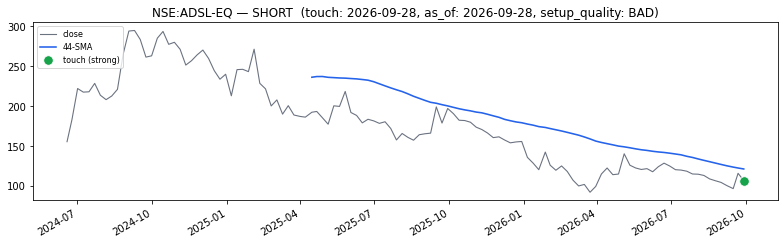

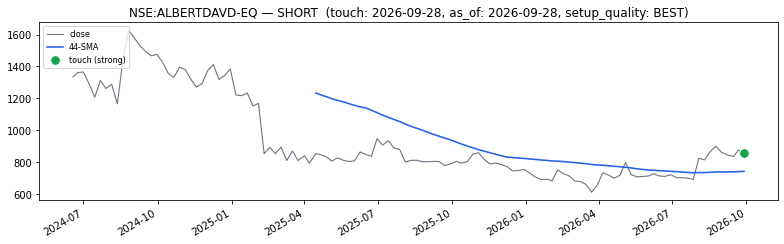

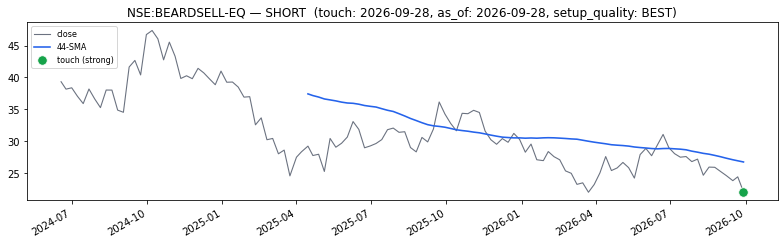

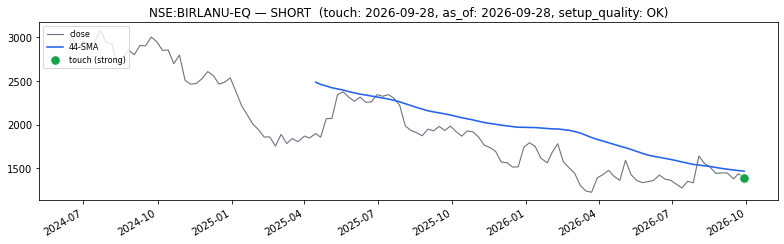

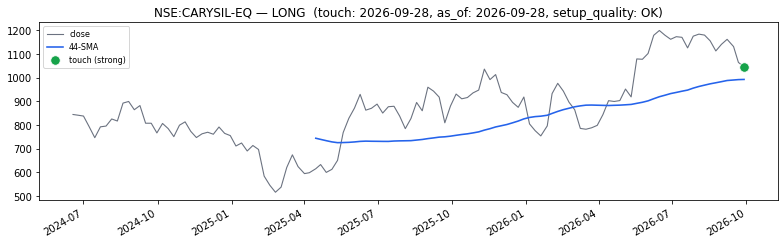

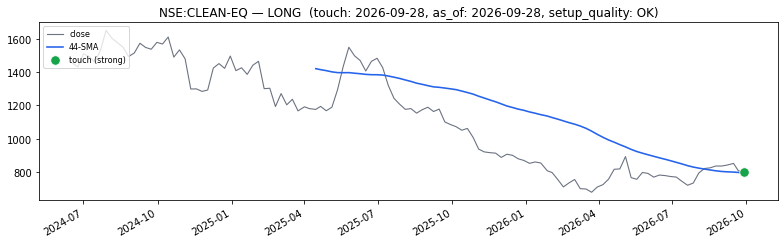

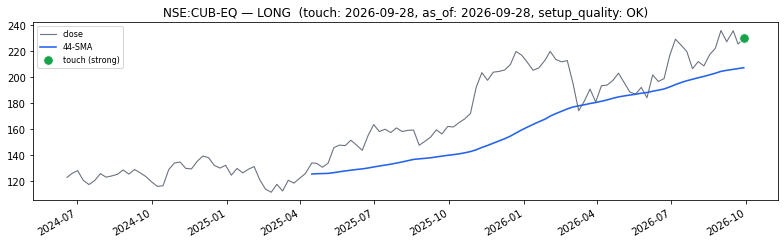

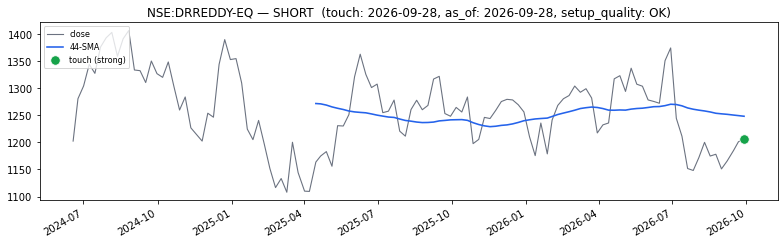

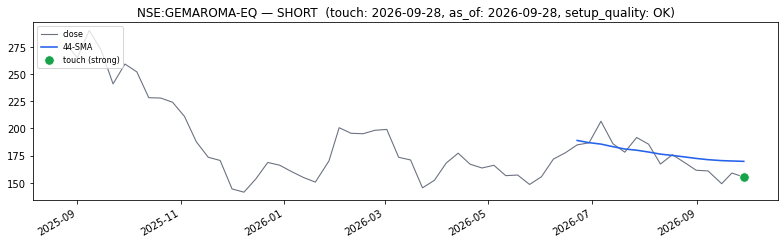

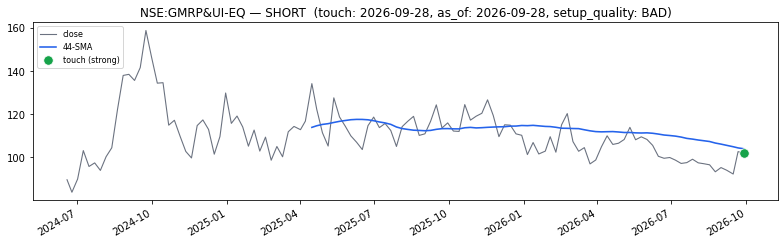

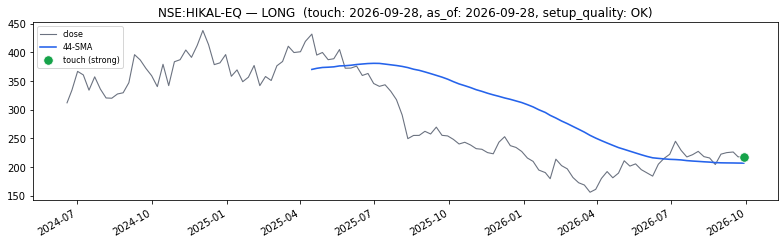

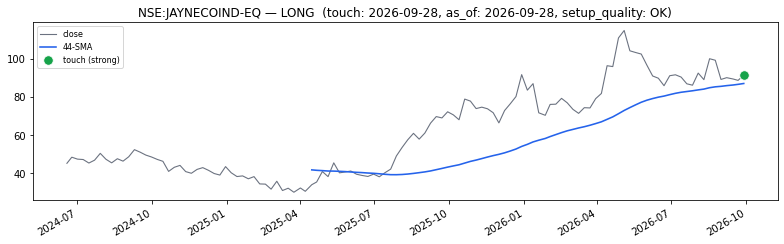

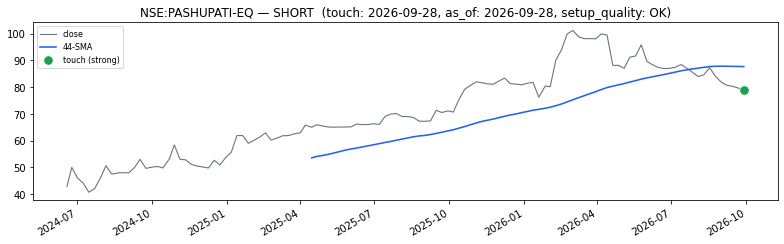

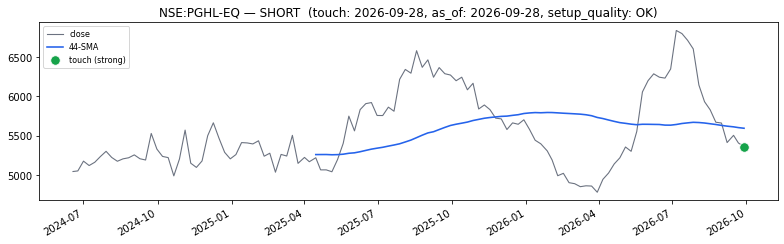

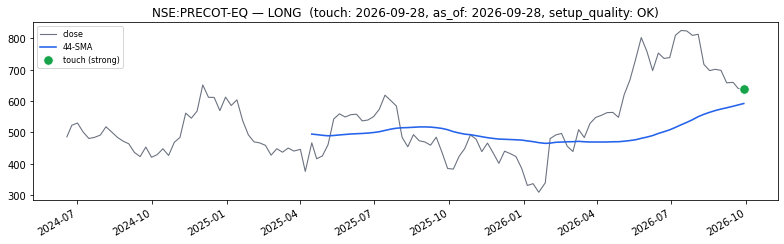

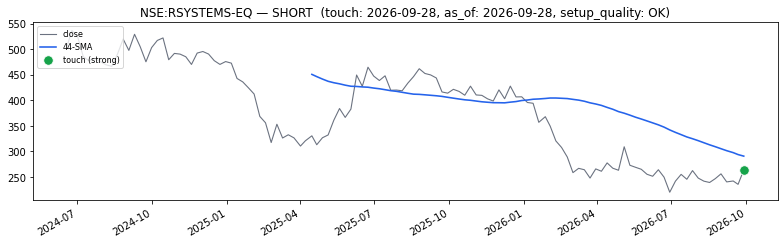

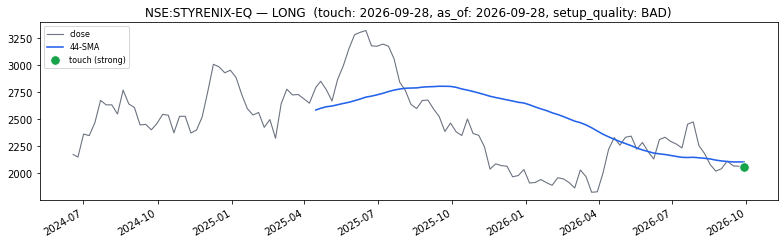

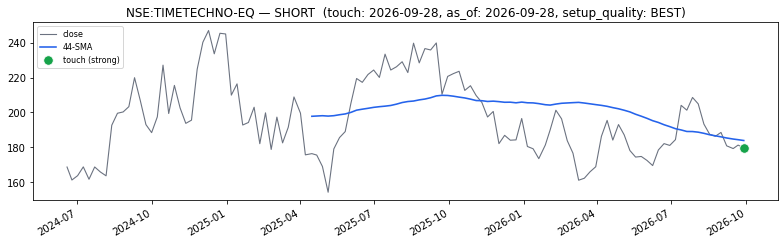

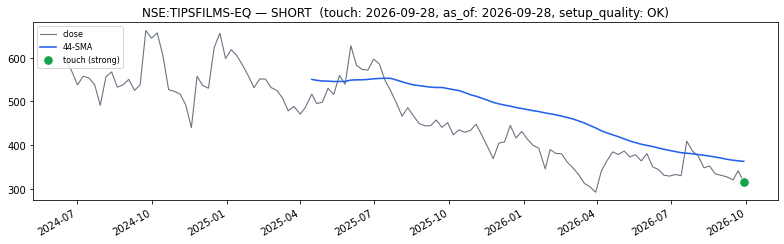

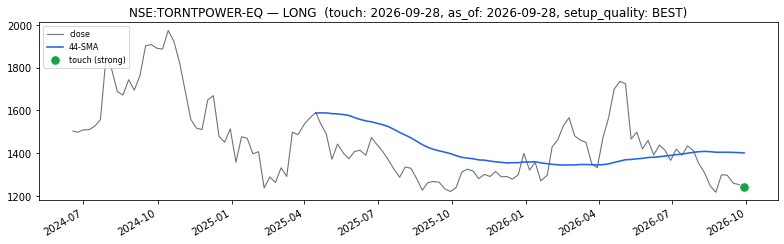

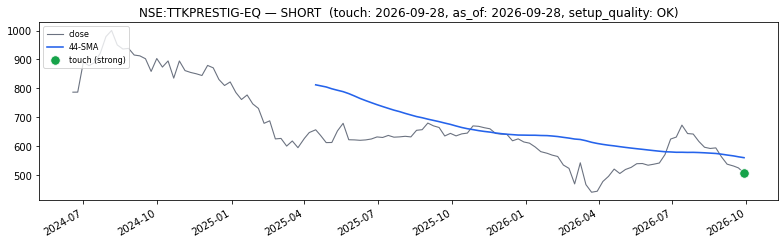

In [13]:
def plot_symbol_scan(symbol, bars, direction, touch_date, is_strong, setup_quality):
    sma = bars['close'].rolling(config.scanner.sma_length, min_periods=config.scanner.sma_length).mean()
    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.plot(bars['timestamp'], bars['close'], color='#6b7280', lw=1.1, label='close')
    ax.plot(bars['timestamp'], sma, color='#2563eb', lw=1.6, label=f'{config.scanner.sma_length}-SMA')

    # Mark the ACTUAL touch candle (touch_date), not just the latest bar —
    # they can differ (see the as_of vs touch_date note above).
    touch_rows = bars[bars['timestamp'] == touch_date]
    marker_color = '#16a34a' if is_strong else '#c2410c'  # green=tradeable, orange=weak/skipped
    if not touch_rows.empty:
        ax.scatter(touch_rows['timestamp'], touch_rows['close'], color=marker_color, s=90, zorder=6,
                   edgecolors='white', linewidths=0.8,
                   label=f'touch ({"strong" if is_strong else "weak"})')
    ax.set_title(f'{symbol} — {direction}  (touch: {pd.Timestamp(touch_date).date()}, '
                f'as_of: {bars["timestamp"].iloc[-1].date()}, setup_quality: {setup_quality})')
    ax.legend(loc='upper left', fontsize=8)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

if not live_df.empty:
    # Zoom each chart to roughly the last 120 bars so the recent touch is legible.
    for _, row in live_df.iterrows():
        bars = market_bars[row['symbol']]
        plot_symbol_scan(row['symbol'], bars.tail(120).reset_index(drop=True), row['direction'],
                         row['touch_date'], row['is_strong_candle'], row['setup_quality'])

## Backtest — turn candidates into an actual trade journal

Reuses `market_bars` from the scan above — no re-fetching. Runs the full
trade pipeline: `generate_scan_candidates` (each qualifying touch that also
passes the candle-strength AND 200-SMA filters -> trigger/stop/target) into
`ScannerBacktester` (entries, the pre-entry invalidation rule, exits,
position sizing, costs). See `STOP_LOSS_OVERRIDES` / `TARGET_OVERRIDES` /
`MA200_FILTER_OVERRIDES` in Parameters for the exact trade rules this applies
(same 7-rule numbering as there):

1. entry only once price breaks back past the touch candle's own high (long) /
   low (short).
2. the stop is the widest of: the touch candle + `stop_lookback_bars` before
   it, and the 44-SMA's own value at the touch (never inside the support line).
3. one open position per symbol at a time.
4. if the stop level breaches before entry, the setup is invalidated outright
   (same-bar ambiguity resolved by the bar's own OHLC shape).
5. a setup not triggered within `setup_expiry_bars` is cancelled.
6. target = entry +/- `risk_reward` * either the signal candle's own
   (high - low) [`target_mode='signal_candle_range'`, default] or (entry -
   stop) itself [`'dynamic_stop_multiple'`].
7. a touch is rejected outright if a 200-SMA sits on the far side of the
   44-SMA from price AND within `nearby_tolerance_pct` of the touch candle's
   own close.

Runs over the FULL scanned history, same reasoning as the scan section above
(a sequence that started before REPORT_FROM_DATE still needs correct
tracking); the summary/journal below are filtered to REPORT_FROM_DATE by
`entry_time`.

In [14]:
t0 = _time.time()
bar_frames = []
candidate_frames = []
dropped_short_no_fno = 0
for sym, bars in market_bars.items():
    bar_frames.append(bars)
    candidates = generate_scan_candidates(bars, config)
    if candidates.empty:
        continue
    if sym not in fno_symbols:
        # Can't actually short this one (no F&O market to borrow via) — LONG
        # candidates on the same symbol are unaffected.
        is_short = candidates['direction'] == 'SHORT'
        dropped_short_no_fno += int(is_short.sum())
        candidates = candidates[~is_short]
    if not candidates.empty:
        candidate_frames.append(candidates)

combined_bars = pd.concat(bar_frames, ignore_index=True)
combined_candidates = pd.concat(candidate_frames, ignore_index=True) if candidate_frames else pd.DataFrame()
print(f'{len(combined_candidates)} tradeable candidates (strong-candle touches, F&O-filtered shorts) '
     f'across {len(market_bars)} symbols  ({dropped_short_no_fno} SHORT candidates dropped -- no F&O market)')

engine = ScannerBacktester(config)
result = engine.run(combined_bars, combined_candidates)
trades, rejected = result['trades'], result['rejected']
print(f'Backtest done in {_time.time()-t0:.0f}s -- {len(trades)} trades, {len(rejected)} rejected setups')

2913 tradeable candidates (strong-candle touches, F&O-filtered shorts) across 2294 symbols  (2231 SHORT candidates dropped -- no F&O market)
Backtest done in 819s -- 1459 trades, 1445 rejected setups


## Backtest summary (filtered to REPORT_FROM_DATE by entry_time)

`exit_reason` values you'll see in the journal below:
- **`target`** / **`sl`** — hit the target or the stop (rule 6/2).
- **`force_exit`** — closed at the configured `force_exit_time` (intraday
  timeframes only — irrelevant here since TIMEFRAME is daily/weekly and
  `continuous_session` is on for the backtest, see Parameters).
- **`time_exit`** — the trade was STILL OPEN when the data simply ran out
  (END_DATE reached before either the target or the stop was hit) — the
  engine force-closes it at that symbol's last known close purely so the
  backtest has a final P&L number for it, not because anything actually
  happened in the market. A real position wouldn't do this — treat these as
  "still running, outcome unknown" rather than a genuine win/loss, and expect
  more of them the closer END_DATE is to today.
- **`daily_loss_exit`** — the daily-loss circuit breaker force-closed it.

In [15]:
if REPORT_FROM_DATE is not None and not trades.empty:
    report_trades = trades[trades['entry_time'] >= REPORT_FROM_DATE].reset_index(drop=True)
else:
    report_trades = trades

# Tag every trade with the SAME setup-quality/candle-strength columns shown
# in the scan section above (see events_df_all, kept unfiltered precisely for
# this — a trade's own ENTRY can land after REPORT_FROM_DATE even when the
# touch that produced it was earlier), matched on (symbol, direction,
# current_touch_time) — the one signal a trade's trigger/stop/target came
# from. is_strong_candle is trivially True for every row here (only strong
# candles ever become candidates) — included anyway for a complete picture.
if not report_trades.empty:
    tag_cols = ['symbol', 'direction', 'ma_length', 'timestamp', 'is_strong_candle', 'swing_bars',
                'pullback_bullish_count', 'is_double_bottom', 'is_resistance_flip',
                'is_range_bound', 'is_violent_pullback', 'setup_quality']
    tags = events_df_all[tag_cols].rename(columns={'timestamp': 'current_touch_time'})
    report_trades = report_trades.merge(tags, on=['symbol', 'direction', 'ma_length', 'current_touch_time'], how='left')

if report_trades.empty:
    print('No trades in the reporting window.')
else:
    summary = build_summary(report_trades)
    print(f"Trades: {summary['total_trades']}   Win rate: {summary['win_rate']:.1f}%")
    print(f"Gross P&L: {summary['gross_pnl']:,.2f}   Net P&L: {summary['net_pnl']:,.2f}")
    print(f"Avg R multiple: {summary['average_r_multiple']:.2f}   Profit factor: {summary['profit_factor']:.2f}")
    print(f"Max drawdown: {summary['max_drawdown']:,.2f} ({summary['max_drawdown_pct']:.1f}%)")
    print()
    display(pd.DataFrame([summary['long_performance'], summary['short_performance']], index=['LONG', 'SHORT']))

Trades: 259   Win rate: 42.5%
Gross P&L: 1,246,924.85   Net P&L: 1,246,924.85
Avg R multiple: 0.20   Profit factor: 1.49
Max drawdown: 592,003.40 (330.9%)



,trades,win_rate,net_pnl,avg_r_multiple
LONG,214,40.186916,1.131730e+06,0.205839
SHORT,45,53.333333,1.151947e+05,0.160474


## Performance by setup quality

A starting point for exactly this kind of filtering — group by any of the
tag columns (`setup_quality`, `is_double_bottom`, `is_resistance_flip`,
`is_range_bound`, `swing_bars`, ...) the same way to compare performance
across setups. The full tagged journal (below) has everything needed to
slice this however you want, in the notebook or in the exported CSV.

In [16]:
if report_trades.empty:
    print('No trades to break down.')
else:
    by_quality = report_trades.groupby('setup_quality').agg(
        trades=('net_pnl', 'count'),
        win_rate=('net_pnl', lambda s: (s > 0).mean() * 100),
        net_pnl=('net_pnl', 'sum'),
        avg_r_multiple=('r_multiple', 'mean'),
    ).reindex(['BEST', 'OK', 'BAD'])
    display(by_quality)

,trades,win_rate,net_pnl,avg_r_multiple
setup_quality,,,,
BEST,27,51.851852,40490.039268,0.191840
OK,171,43.274854,617629.330299,0.162572
BAD,61,36.065574,588805.482619,0.299859


## Trade journal — fully tagged (exported to CSV)

In [17]:
if not report_trades.empty:
    report_trades = report_trades.copy()
    report_trades['is_etf'] = report_trades['symbol'].isin(etf_symbols)
    cols = ['symbol', 'is_etf', 'direction', 'ma_length', 'ma_alignment',
            'confluence_gap_skipped', 'confluence_gap_ma', 'confluence_gap_atr', 'touch_count', 'trend_class', 'ma_slope_pct', 'daily_volume',
            'min5_trend_class', 'min15_trend_class', 'min30_trend_class', 'hourly_trend_class',
            'daily_trend_class', 'weekly_trend_class', 'monthly_trend_class',
            'entry_time', 'entry_price',
            'initial_stop', 'stop_loss', 'target', 'exit_time', 'exit_price',
            'exit_reason', 'qty', 'net_pnl', 'r_multiple', 'holding_minutes',
            'is_strong_candle', 'swing_bars', 'pullback_bullish_count',
            'is_double_bottom', 'is_resistance_flip', 'is_range_bound', 'is_violent_pullback', 'setup_quality']
    journal = report_trades[cols].sort_values('entry_time').reset_index(drop=True)
    display(journal)
    TRADE_JOURNAL_CSV.parent.mkdir(parents=True, exist_ok=True)
    journal.to_csv(TRADE_JOURNAL_CSV, index=False)
    print(f'written: {TRADE_JOURNAL_CSV}')
else:
    print('Nothing to export.')

,symbol,is_etf,direction,ma_length,ma_alignment,confluence_gap_skipped,confluence_gap_ma,confluence_gap_atr,touch_count,trend_class,ma_slope_pct,daily_volume,min5_trend_class,min15_trend_class,min30_trend_class,...,exit_time,exit_price,exit_reason,qty,net_pnl,r_multiple,holding_minutes,is_strong_candle,swing_bars,pullback_bullish_count,is_double_bottom,is_resistance_flip,is_range_bound,is_violent_pullback,setup_quality
0,NSE:GODREJPROP-EQ,False,LONG,200,D,False,None,NaN,2,A,0.691847,1593781,None,None,None,...,2026-01-12 05:30:00+05:30,1938.761429,sl,95.0,-13797.664286,-1.000000,10080.0,True,3,0,False,False,False,False,OK
1,NSE:HDFCLIFE-EQ,False,LONG,50,A,False,None,NaN,3,A,1.940364,21479930,None,None,None,...,2026-01-12 05:30:00+05:30,728.514571,sl,262.0,-8549.546571,-1.000000,10080.0,True,38,10,False,False,True,False,OK
2,NSE:SIEMENS-EQ,False,LONG,50,B,False,None,NaN,5,C,-0.188547,1030284,None,None,None,...,2026-01-12 05:30:00+05:30,2979.049286,sl,63.0,-9572.895000,-1.000000,10080.0,True,3,0,False,False,False,True,BAD
3,NSE:SUNPHARMA-EQ,False,LONG,44,B,True,30,0.210715,2,A,0.486902,7720390,None,None,None,...,2026-01-12 05:30:00+05:30,1738.000000,trail_stop,115.0,0.000000,0.000000,10080.0,True,10,0,False,False,False,True,BAD
4,NSE:BAJAJFINSV-EQ,False,LONG,50,A,False,None,NaN,2,A,2.108951,9407883,None,None,None,...,2026-01-19 05:30:00+05:30,1971.827857,sl,97.0,-8455.697857,-1.000000,20160.0,True,52,15,False,True,True,False,OK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254,NSE:ASHIANA-EQ,False,LONG,50,A,False,None,NaN,3,A,1.579725,158528,None,None,None,...,2026-09-21 05:30:00+05:30,383.950000,time_exit,541.0,7870.777143,0.344485,0.0,True,28,5,False,True,True,False,OK
255,NSE:TRENT-EQ,False,LONG,200,C,False,None,NaN,3,A,1.782299,2499930,None,None,None,...,2026-09-21 05:30:00+05:30,2695.928957,sl,70.0,-10224.973000,-1.000000,0.0,True,27,2,False,False,True,False,OK
256,NSE:REGAAL-EQ,False,LONG,44,D,False,None,NaN,2,C,-0.133901,991092,None,None,None,...,2026-09-28 05:30:00+05:30,87.010357,trail_stop,2298.0,0.000000,0.000000,10080.0,True,11,0,False,True,False,True,BAD
257,NSE:MOTISONS-EQ,False,LONG,50,C,True,"30,44",0.172054,2,C,-1.254785,453501495,None,None,None,...,2026-09-21 05:30:00+05:30,17.880000,time_exit,10358.0,-14781.605857,-0.294780,0.0,True,5,0,False,False,False,False,OK


written: /home/rahul/trading2/trading_bot/artifacts/scanner_universe_backtest_trades.csv


In [18]:
# per_trade_amount = 200000
# journal['pnl'] = journal['net_pnl'] * (per_trade_amount/journal['entry_price'])

In [19]:
# journal['pnl'].sum()

In [20]:
# journal[journal['exit_reason'] == 'sl']

## P&L analysis (normalized to a fixed `per_trade_amount`)

`journal['pnl']` above rescales each trade's `net_pnl` (computed at
`config.risk.fixed_qty` — 1 share/lot per trade) as if every trade instead
deployed a fixed `per_trade_amount` (₹200,000) of capital: `net_pnl *
(per_trade_amount / entry_price)`. This makes trades comparable across very
differently-priced symbols — a ₹50 stock and a ₹5,000 stock each get sized
to the same rupee exposure, rather than the notebook's actual `qty=1`
backtest sizing (which — see `config.risk` in Parameters — isn't meant to
represent real position sizing at all).

P&L below is realized at **exit**, not entry — a trade's outcome only
counts toward a given day/month once it's actually closed.

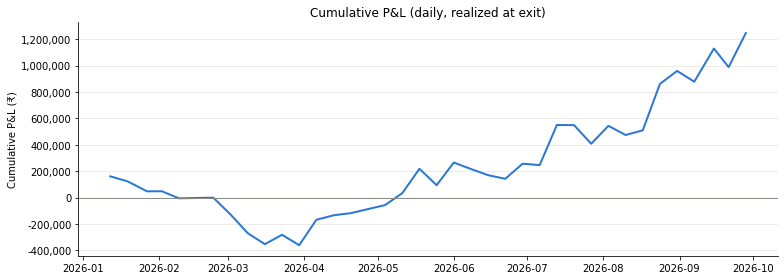

In [21]:
daily_pnl = journal.assign(exit_date=journal['exit_time'].dt.floor('D')) \
    .groupby('exit_date')['net_pnl'].sum().sort_index()
cum_daily_pnl = daily_pnl.cumsum()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(cum_daily_pnl.index, cum_daily_pnl.values, color='#2a78d6', linewidth=2)
ax.axhline(0, color='#8a8983', linewidth=1)
ax.set_title('Cumulative P&L (daily, realized at exit)')
ax.set_ylabel('Cumulative P&L (\u20b9)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.grid(axis='y', color='#e8e7e2', linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

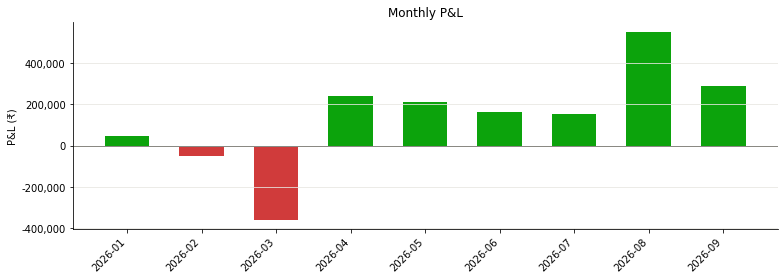

In [22]:
monthly_pnl = journal.assign(exit_month=journal['exit_time'].dt.tz_localize(None).dt.to_period('M')) \
    .groupby('exit_month')['net_pnl'].sum().sort_index()
bar_colors = ['#0ca30c' if v >= 0 else '#d03b3b' for v in monthly_pnl.values]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(monthly_pnl.index.astype(str), monthly_pnl.values, color=bar_colors, width=0.6)
ax.axhline(0, color='#8a8983', linewidth=1)
ax.set_title('Monthly P&L')
ax.set_ylabel('P&L (\u20b9)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.grid(axis='y', color='#e8e7e2', linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

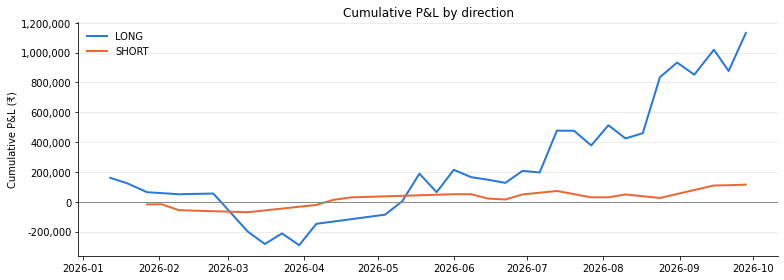

,trades,win_rate,total_pnl,avg_pnl
direction,,,,
LONG,214,40.186916,1.131730e+06,5288.458515
SHORT,45,53.333333,1.151947e+05,2559.882890


In [23]:
DIRECTION_COLORS = {'LONG': '#2a78d6', 'SHORT': '#eb6834'}

fig, ax = plt.subplots(figsize=(11, 4))
for direction, color in DIRECTION_COLORS.items():
    sub = journal[journal['direction'] == direction]
    if sub.empty:
        continue
    daily = sub.assign(exit_date=sub['exit_time'].dt.floor('D')).groupby('exit_date')['net_pnl'].sum().sort_index()
    ax.plot(daily.cumsum().index, daily.cumsum().values, color=color, linewidth=2, label=direction)
ax.axhline(0, color='#8a8983', linewidth=1)
ax.set_title('Cumulative P&L by direction')
ax.set_ylabel('Cumulative P&L (\u20b9)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.grid(axis='y', color='#e8e7e2', linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

display(journal.groupby('direction').agg(
    trades=('net_pnl', 'count'),
    win_rate=('net_pnl', lambda s: (s > 0).mean() * 100),
    total_pnl=('net_pnl', 'sum'),
    avg_pnl=('net_pnl', 'mean'),
))

### Max capital utilization

How much capital would actually need to be available at once to take every
trade the strategy fired, given each trade deploys `per_trade_amount` for
its full holding period (`entry_time` through `exit_time`, inclusive — since
`one_active_position_per_symbol` only caps concurrency PER symbol, multiple
symbols can easily be open at the same time).

Max capital utilization: ₹17,157,924  (~86 concurrent positions)  on 2026-06-15


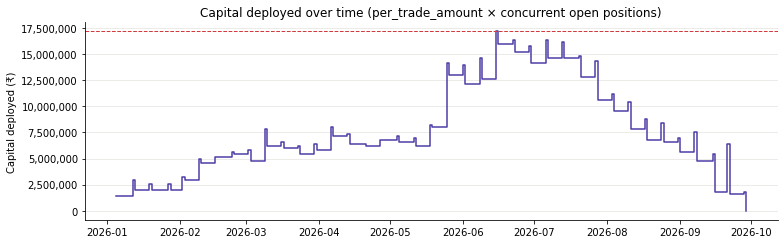

In [24]:
entry_dates = journal['entry_time'].dt.floor('D')
exit_dates = journal['exit_time'].dt.floor('D')
journal['per_trade_amount'] = journal['entry_price'] * journal['qty']
per_trade_amount = journal['per_trade_amount'].mean()

# +per_trade_amount the day a position opens, -per_trade_amount the day AFTER
# it closes (it's still deployed on its own exit day) -> cumsum = capital
# actually deployed on any given day.
capital_events = pd.concat([
    pd.Series(per_trade_amount, index=entry_dates),
    pd.Series(-per_trade_amount, index=exit_dates + pd.Timedelta(days=1)),
]).groupby(level=0).sum().sort_index()
capital_timeline = capital_events.cumsum()

max_capital = capital_timeline.max()
max_capital_date = capital_timeline.idxmax()
max_concurrent_positions = round(max_capital / per_trade_amount)

print(f'Max capital utilization: \u20b9{max_capital:,.0f}  '
      f'(~{max_concurrent_positions} concurrent positions)  on {max_capital_date.date()}')

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.step(capital_timeline.index, capital_timeline.values, color='#4a3aa7', linewidth=1.5, where='post')
ax.axhline(max_capital, color='#d03b3b', linewidth=1, linestyle='--')
ax.set_title('Capital deployed over time (per_trade_amount \u00d7 concurrent open positions)')
ax.set_ylabel('Capital deployed (\u20b9)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.grid(axis='y', color='#e8e7e2', linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Rejected setups — why a candidate never became a trade

`stop_breached_before_entry` is the pre-entry invalidation rule (rule 4 —
the stop level was breached before the trigger); `setup_expired` is the
3-bar (or configured) expiry (rule 5); the rest are the existing
trade-limit/timing gates (unrelated to these 7 rules).

In [25]:
if rejected.empty:
    print('No rejected setups.')
else:
    rejected_report = rejected[rejected['timestamp'] >= REPORT_FROM_DATE] if REPORT_FROM_DATE is not None else rejected
    if rejected_report.empty:
        print('No rejected setups in the reporting window.')
    else:
        display(rejected_report['reason'].value_counts().to_frame('count'))

,count
setup_expired,136
stop_breached_before_entry,110
one_active_position_per_symbol,37
